In [1]:
!rm -rf diploma_centpy_parallelization_py
# Флаг -b указывает конкретную ветку
!git clone -b feature/jax-centpy https://github.com/filkinc/diploma_centpy_parallelization_py.git
%cd diploma_centpy_parallelization_py
%cd /content/diploma_centpy_parallelization_py/jax_centpy

# Установка зависимостей
!pip install centpy pandas matplotlib seaborn scienceplots

Cloning into 'diploma_centpy_parallelization_py'...
remote: Enumerating objects: 606, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 606 (delta 7), reused 16 (delta 5), pack-reused 537 (from 2)
Receiving objects: 100% (606/606), 60.49 MiB | 21.37 MiB/s, done.
Resolving deltas: 100% (266/266), done.
/content/diploma_centpy_parallelization_py
/content/diploma_centpy_parallelization_py/jax_centpy


In [2]:
!git clone https://github.com/tumaer/JAXFLUIDS.git
!pip install -e JAXFLUIDS

Cloning into 'JAXFLUIDS'...
remote: Enumerating objects: 2563, done.
remote: Counting objects: 100% (689/689), done.
remote: Compressing objects: 100% (230/230), done.
remote: Total 2563 (delta 539), reused 508 (delta 459), pack-reused 1874 (from 2)
Receiving objects: 100% (2563/2563), 13.19 MiB | 9.82 MiB/s, done.
Resolving deltas: 100% (1474/1474), done.
Obtaining file:///content/diploma_centpy_parallelization_py/jax_centpy/JAXFLUIDS
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jaxfluids (pyproject.toml) ... done
  Created wheel for jaxfluids: filename=jaxfluids-0.2.1-0.editable-py3-none-any.whl size=4993 sha256=1792928049b47b566a91ff8c59f288b9b5c0ef78d40f12052b417deb62377191
  Stored in directory: /tmp/pip-ephem-wheel-cache-8b0leb4n/wheels/0d/f5/f7/36c7ba3191fe532ed59d9727c10bd83ddce132ae2a04111c95


In [3]:
import os
import time
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
from google.colab import files
from typing import Callable, NamedTuple

from core import Pars2d, Equation2d, Pars1d, Equation1d
from solver import Solver1d, FastSolver1d, FastSolverWithAllLayersWithoutExtends1d
from boundaries import periodic_bc_2d, neumann_bc_2d, dirichlet_riemann_bc_2d, periodic_bc, wall_bc_1d, neumann_bc
from equations import make_euler_riemann_2d, make_euler_isentropic_vortex_2d, make_burgers_1d
from schemes import compute_rhs_sd2_2d
from limiters import monotonized_central, minmod
from richardson import self_convergence_analysis

In [4]:
def make_modified_sod(gamma=1.4, alpha: float = 0.1) -> Equation1d:
    def compute_pressure(q):
        rho = q[..., 0]
        u = q[..., 1] / rho
        E = q[..., 2]
        return (gamma - 1.0) * (E - 0.5 * rho * u**2)

    def flux(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        E = q[..., 2]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = compute_pressure(q)
        return jnp.stack([rhou, rhou * u + p, u * (E + p)], axis=-1)

    def spectral_radius(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = jnp.maximum(compute_pressure(q), 1e-10)
        c = jnp.sqrt(gamma * p / rhosafe)
        a = jnp.abs(u) + c
        return a[..., None]

    def initial_data(x):
        # Невозмущенный газ
        rho_0, p_0 = 1.0, 1.0

        # Состояние за ударной волной (по Ренкину-Гюгонио для M=2)
        rho_R = 2.66666666667
        p_R = 4.5
        u_R = -1.47901994677

        # Границы областей
        x_0 = 0.3
        x_1 = 0.5
        x_sw = 0.8

        # Кусочно-постоянное распределение плотности
        rho = jnp.where(x < x_0, rho_0,
                jnp.where(x <= x_1, alpha * rho_0,
                jnp.where(x < x_sw, rho_0, rho_R)))

        # Распределение скорости (движется только газ за фронтом УВ)
        u = jnp.where(x < x_sw, 0.0, u_R)

        # Распределение давления
        p = jnp.where(x < x_0, p_0,
                jnp.where(x <= x_1, p_0,
                jnp.where(x < x_sw, p_0, p_R)))

        E = p / (gamma - 1.0) + 0.5 * rho * u**2
        return jnp.stack([rho, rho * u, E], axis=-1)

    def mixed_bc(u, n_ghost):
        # Левая граница: условия Неймана (нулевой градиент / свободный выход волны)
        # Повторяем значения из первой внутренней ячейки (index 0) n_ghost раз.
        left_ghost = jnp.repeat(u[:1], n_ghost, axis=0)

        # Правая граница: непротекание (твердая стенка)
        # Зеркальное отражение плотности и энергии, но смена знака для импульса (u[:, 1]).
        right_ghost = u[-n_ghost:][::-1]
        right_ghost = right_ghost.at[:, 1].set(-right_ghost[:, 1])

        # Склеиваем фиктивные ячейки с основной расчетной областью
        return jnp.concatenate([left_ghost, u, right_ghost], axis=0)

    return Equation1d(
        flux=flux,
        spectral_radius=spectral_radius,
        initial_data=initial_data,
        boundary_handler=mixed_bc,  # Подключаем наши новые смешанные условия
        name="Modified Sod (Left: Neumann, Right: Wall)"
    )

In [6]:
# Инициализация уравнения и параметров
eqn = make_modified_sod()
pars = Pars1d(x_init=0.0, x_final=1.0, t_final=0.4, dt_out=0.2, J=400, cfl=0.45)
solver = FastSolverWithAllLayersWithoutExtends1d(pars, eqn, scheme_name='sd2', limiter_name="minmod")

print("Запуск расчёта...")
t0 = time.time()
sol = solver.solve()
t1 = time.time()
print(f"\n[GPU JAX] Чистое время выполнения: {t1 - t0:.4f} секунд")
print("Расчёт успешно завершён!")

# Извлечение результатов
x_num = np.array(sol["x"])
t_num = np.array(sol["t"])
q_num = np.array(sol["u_n"])

# Декодирование консервативных переменных в примитивные
rho_num = q_num[..., 0]
u_num = q_num[..., 1] / q_num[..., 0]
p_num = 0.4 * (q_num[..., 2] - 0.5 * rho_num * u_num**2)

Запуск расчёта...

[GPU JAX] Чистое время выполнения: 1.2457 секунд
Расчёт успешно завершён!


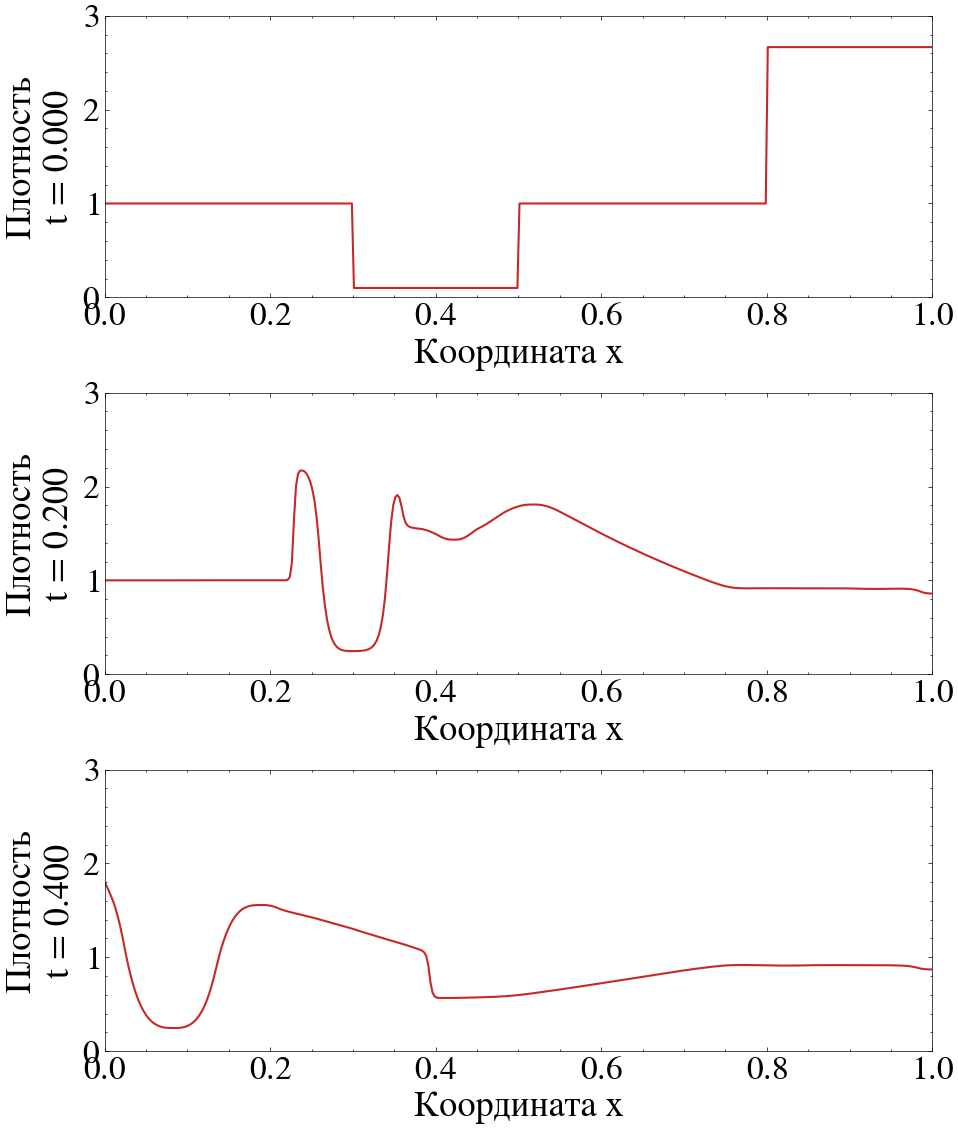

Сохранено: rho_evolution.png


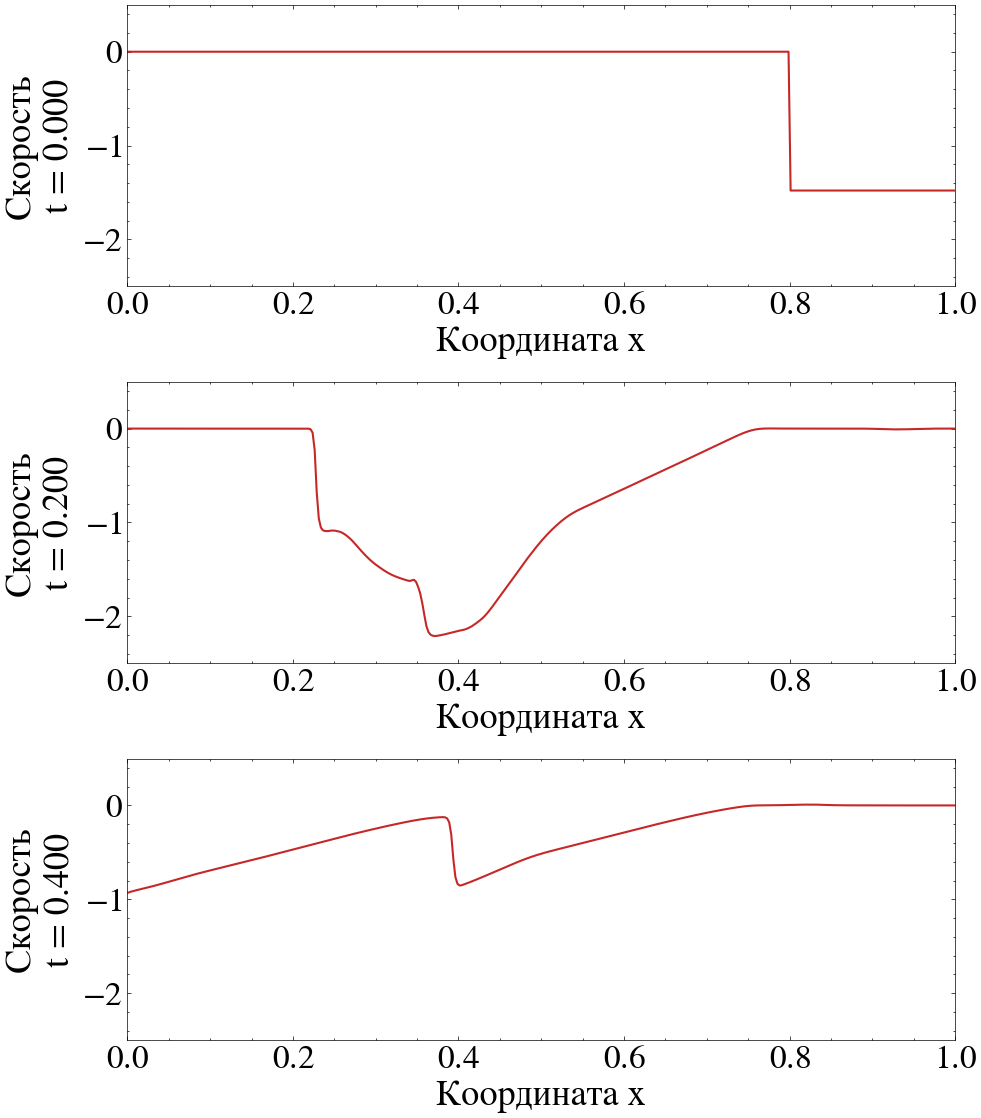

Сохранено: u_evolution.png


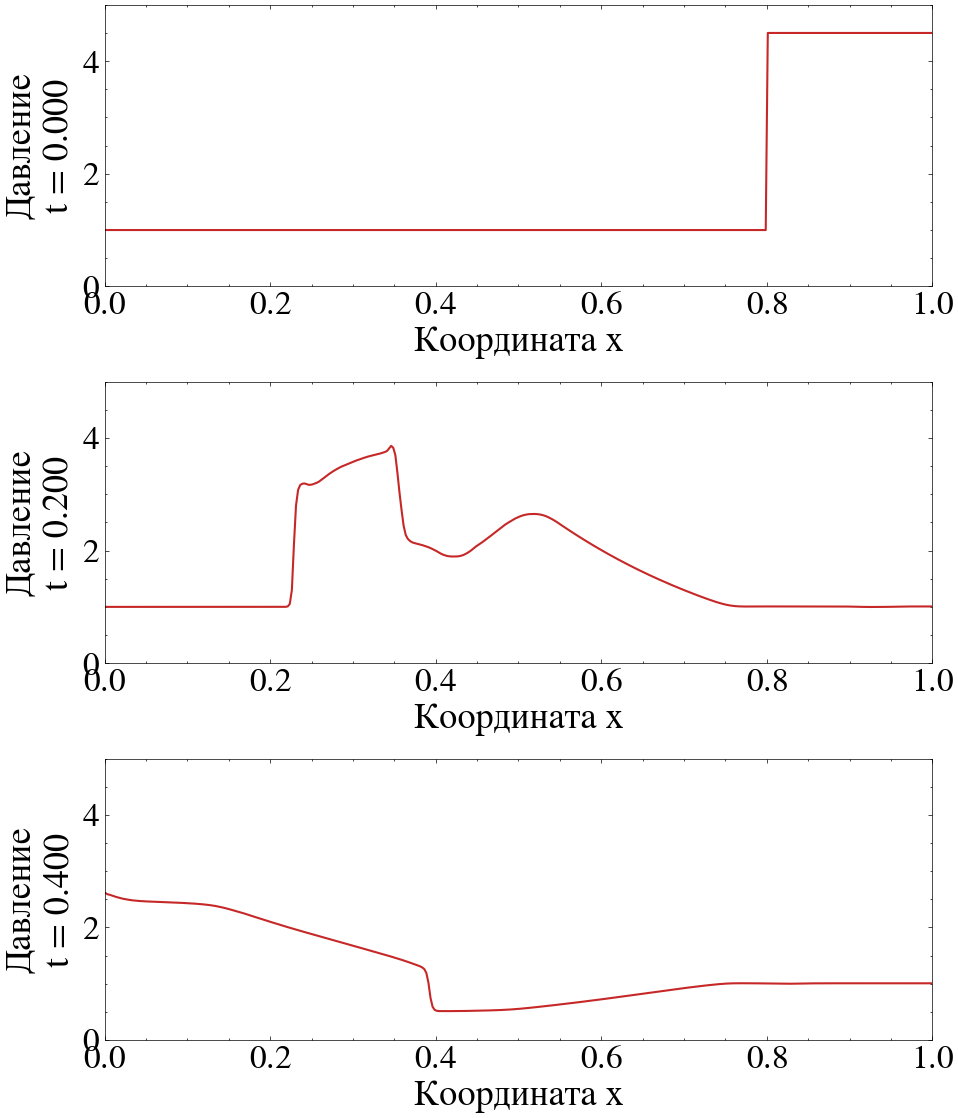

Сохранено: p_evolution.png


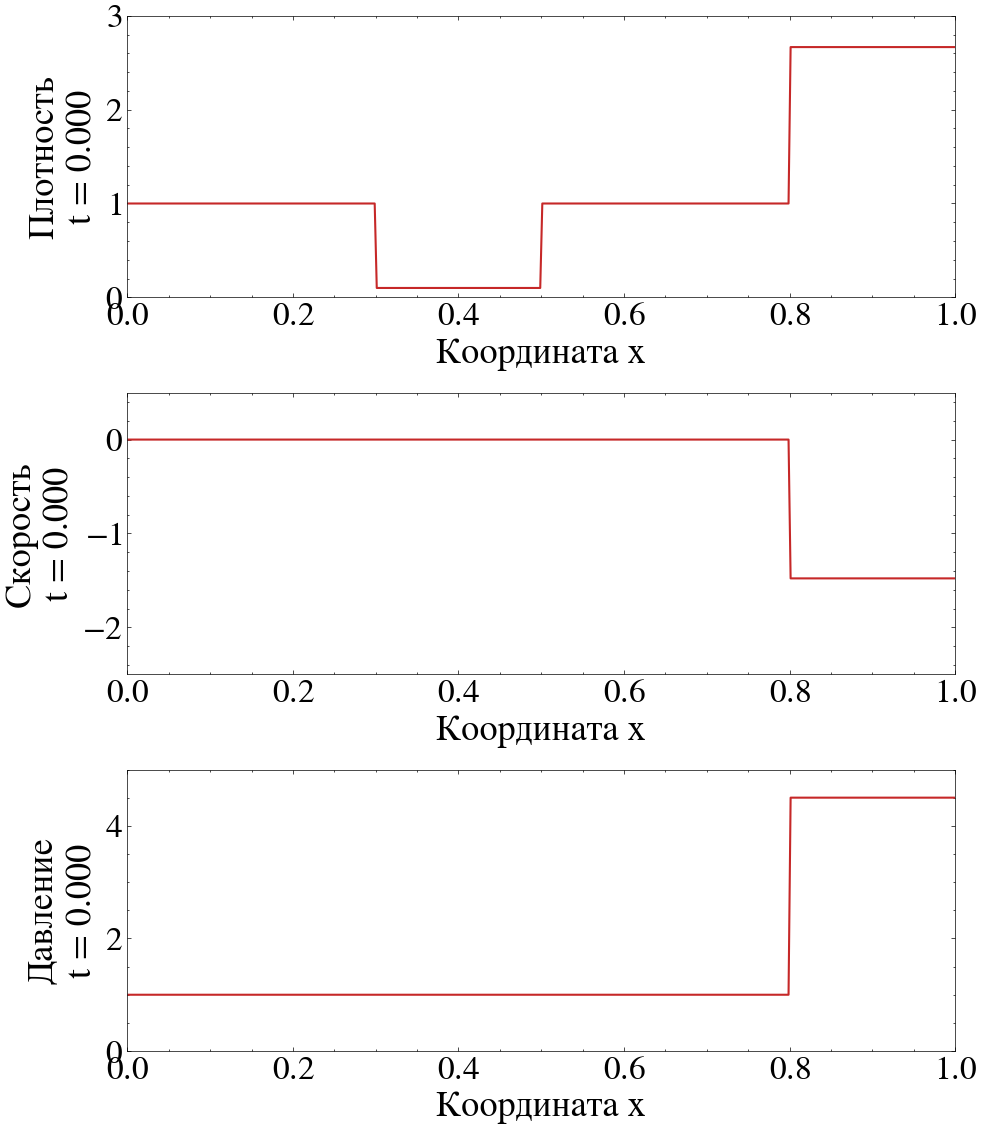

Сохранено: combined_final_state.png


In [7]:
import scienceplots
import matplotlib.pyplot as plt

plt.style.use(['science', 'no-latex'])

# Индексы трёх моментов времени
idx_start = 0
idx_mid   = len(t_num) // 2
idx_end   = len(t_num) - 1

time_indices = [idx_start, idx_mid, idx_end]

# Настройки для каждой переменной
variables = [
    {'data': rho_num, 'ylabel': 'Плотность', 'ylim': (0.0, 3.0),  'color': '#C62828'},
    {'data': u_num,   'ylabel': 'Скорость',   'ylim': (-2.5, 0.5), 'color': '#C62828'},
    {'data': p_num,   'ylabel': 'Давление',   'ylim': (0.0, 5.0),  'color': '#C62828'},
]
filenames = ['rho_evolution.png', 'u_evolution.png', 'p_evolution.png']

# === 1. Графики эволюции каждой переменной во времени ===
for var, fname in zip(variables, filenames):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))
    fig.tight_layout(pad=5.0)

    for row, idx in enumerate(time_indices):
        ax = axes[row]
        ax.plot(x_num, var['data'][idx], color=var['color'], linewidth=1.5)
        ax.set_xlim(0, 1)
        ax.set_ylim(*var['ylim'])
        ax.set_ylabel(f"{var['ylabel']}\nt = {t_num[idx]:.3f}", fontsize=26)

        # Теперь ось x подписывается и отображается на каждом графике
        ax.set_xlabel('Координата x', fontsize=26)
        ax.tick_params(axis='both', labelsize=24)

    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Сохранено: {fname}')


# === 2. Сводный график всех переменных для конечного момента времени ===
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
fig.tight_layout(pad=5.0)
fname_combined = 'combined_final_state.png'

for i, var in enumerate(variables):
    ax = axes[i]
    # Используем данные только для начального момента времени (idx_start)
    ax.plot(x_num, var['data'][idx_start], color=var['color'], linewidth=1.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(*var['ylim'])
    ax.set_ylabel(f"{var['ylabel']}\nt = {t_num[idx_start]:.3f}", fontsize=26)

    # Подписи оси x для каждого подграфика
    ax.set_xlabel('Координата x', fontsize=26)
    ax.tick_params(axis='both', labelsize=24)

fig.savefig(fname_combined, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Сохранено: {fname_combined}')

In [11]:
import json
import numpy as np

# ============================================================
# 1. НАСТРОЙКА РАСЧЁТА (case_setup)
# ============================================================
general = {
    "case_name": "modified_sod_shocktube_neumann",
    "end_time": 0.4,          # <-- было 0.25, стало 0.4
    "save_path": "./results",
    "save_dt": 0.2            # <-- было 0.05: сохраняем t=0, 0.2, 0.4
}

domain = {
    "x": {"cells": 400, "range": [0.0, 1.0]},
    "y": {"cells": 1,   "range": [0.0, 1.0]},
    "z": {"cells": 1,   "range": [0.0, 1.0]}
}

# Ключевое изменение: east = правая граница (x=1) — стенка,
# west = левая граница (x=0) — свободный выход (Нейман)
boundary_conditions = {
    "east": {
        "type": "WALL",
        "wall_velocity_callable": {   # <-- обязательное поле для WALL
            "u": 0.0,                 # неподвижная стенка, все компоненты = 0
            "v": 0.0,
            "w": 0.0
        }
    },
    "west":   {"type": "ZEROGRADIENT"},
    "north":  {"type": "INACTIVE"},
    "south":  {"type": "INACTIVE"},
    "top":    {"type": "INACTIVE"},
    "bottom": {"type": "INACTIVE"}
}

initial_condition = {
    "rho": "lambda x: jnp.where(x < 0.3, 1.0, jnp.where(x <= 0.5, 0.1, jnp.where(x < 0.8, 1.0, 2.66666666667)))",
    "u":   "lambda x: jnp.where(x < 0.8, 0.0, -1.47901994677)",
    "v": 0.0,
    "w": 0.0,
    "p":   "lambda x: jnp.where(x < 0.8, 1.0, 4.5)"
}

material_properties = {
    "equation_of_state": {
        "model": "IdealGas",
        "specific_heat_ratio": 1.4,
        "specific_gas_constant": 1.0
    }
}

output = {
    "primitives": ["density", "velocity", "pressure"]
}

case_setup = {
    "general":              general,
    "domain":               domain,
    "boundary_conditions":  boundary_conditions,
    "initial_condition":    initial_condition,
    "material_properties":  material_properties,
    "output":               output
}

In [12]:
# ============================================================
# 2. ЧИСЛЕННАЯ СХЕМА (numerical_setup) — без изменений
# ============================================================
numerical_setup = {
    "active_physics": {
        "is_convective_flux": True,
        "is_viscous_flux":    False,
        "is_heat_flux":       False,
        "is_volume_force":    False
    },
    "conservatives": {
        "halo_cells": 3,
        "time_integration": {
            "integrator": "RK3",
            "CFL": 0.475         # число Куранта как в вашей схеме
        },
        "convective_fluxes": {
            "convective_solver": "GODUNOV",
            "godunov": {
                "riemann_solver":          "RUSANOV",
                "signal_speed":            "RUSANOV",
                "reconstruction_stencil":  "MINMOD",
                "reconstruction_variable": "CONSERVATIVE"
            }
        },
        "positivity": {
            "flux_limiter":            None,
            "is_interpolation_limiter": True
        }
    },
    "precision": {
        "is_double_precision_compute": True,
        "is_double_precision_output":  True
    },
    "output": {
        "derivative_stencil": "CENTRAL2",
        "logging": {"frequency": 10}
    }
}

with open("case_setup.json", "w") as f:
    json.dump(case_setup, f, indent=2)
with open("numerical_setup.json", "w") as f:
    json.dump(numerical_setup, f, indent=2)

print("Конфигурационные файлы записаны.")

Конфигурационные файлы записаны.


In [13]:
# ============================================================
# 3. ЗАПУСК JAX-FLUIDS
# ============================================================
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('JAXFLUIDS/src'))

from jaxfluids import InputManager, SimulationManager
from jaxfluids.initialization.initialization_manager import InitializationManager

input_manager = InputManager("case_setup.json", "numerical_setup.json")
init_manager  = InitializationManager(input_manager)
jxf_buffers   = init_manager.initialization()

sim_manager = SimulationManager(input_manager)
sim_manager.simulate(jxf_buffers)

*------------------------------------------------------------------------------*
*                                                                              *
*                                                                              *
*          _     _    __  __        _____  _      _   _  ___  ____   ____      *
*         | |   / \   \ \/ /       |  ___|| |    | | | ||_ _||  _ \ / ___|     *
*      _  | |  / _ \   \  /  _____ | |_   | |    | | | | | | | | | |\___ \     *
*     | |_| | / ___ \  /  \ |_____||  _|  | |___ | |_| | | | | |_| | ___) |    *
*      \___/ /_/   \_\/_/\_\       |_|    |_____| \___/ |___||____/ |____/     *
*                                                                              *
*                                By BB - ML@AER                                *
*                                                                              *
*------------------------------------------------------------------------------*
* JAX-FLUIDS -              

In [14]:
# ============================================================
# 4. ЧТЕНИЕ РЕЗУЛЬТАТОВ JAX-FLUIDS
# Файлы сохраняются как: t=0.000.h5, t=0.200.h5, t=0.400.h5
# ============================================================
import h5py, glob

save_times = [0.0, 0.2, 0.4]

# Читаем все три временных среза из отдельных файлов
# JAX-FLUIDS именует файлы по времени: например data_0.000000.h5
h5_files = sorted(glob.glob("./results/**/*.h5", recursive=True))
# Оставляем только 3 нужных (по числу save_dt)
assert len(h5_files) >= 3, f"Ожидалось 3 файла, найдено: {len(h5_files)}"
h5_files = h5_files[:3]   # t=0, 0.2, 0.4

x_jf = None
rho_jf_list, u_jf_list, p_jf_list = [], [], []

for fpath in h5_files:
    with h5py.File(fpath, "r") as f:
        if x_jf is None:
            x_jf = np.array(f["domain/gridX"]).flatten()
        rho_jf_list.append(np.array(f["primitives/density"]).flatten())
        # JAX-FLUIDS хранит вектор скорости, берём x-компоненту (индекс 0)
        u_jf_list.append(np.array(f["primitives/velocity"])[0].flatten())
        p_jf_list.append(np.array(f["primitives/pressure"]).flatten())

In [15]:
# ============================================================
# 5. ВАШИ ДАННЫЕ
# Предполагается, что у вас есть:
#   x_num                — сетка,
#   rho_num, u_num, p_num — списки/массивы по временным слоям
# Индексы слоёв для t=0, 0.2, 0.4 зависят от вашего save_dt.
# Если ваш save_dt тоже 0.2, то индексы 0, 1, 2.
# ============================================================
my_indices = [0, 1, 2]   # скорректируйте при другом save_dt

rho_my_list = [rho_num[i] for i in my_indices]
u_my_list   = [u_num[i]   for i in my_indices]
p_my_list   = [p_num[i]   for i in my_indices]

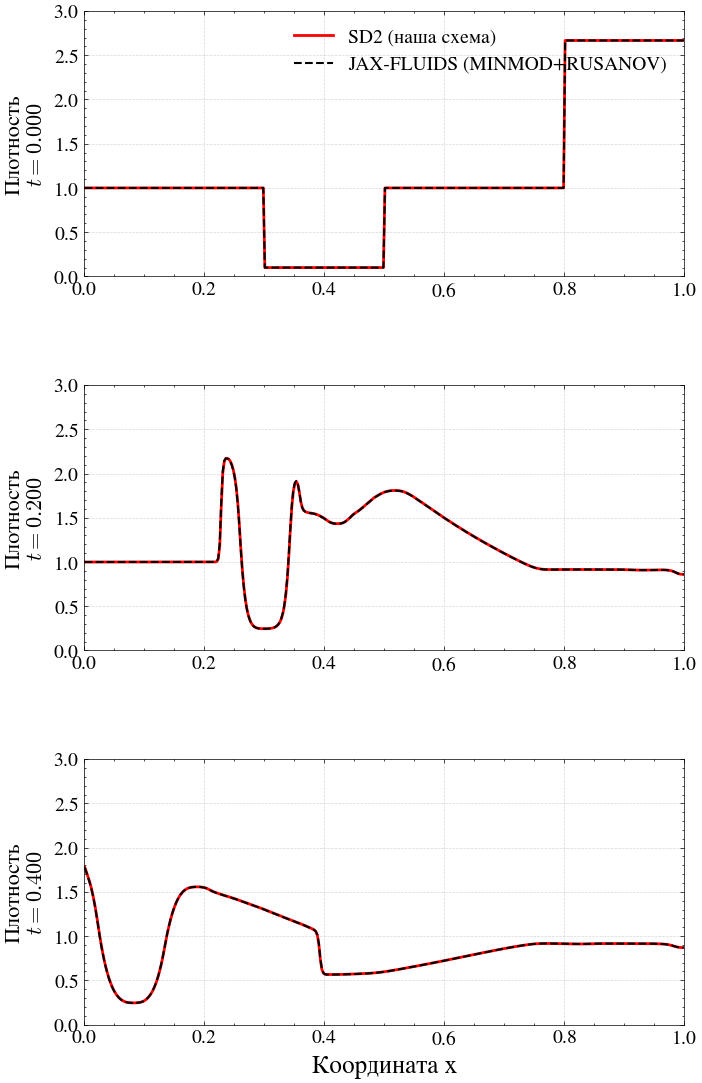

Сохранено: verify_1d_rho.png


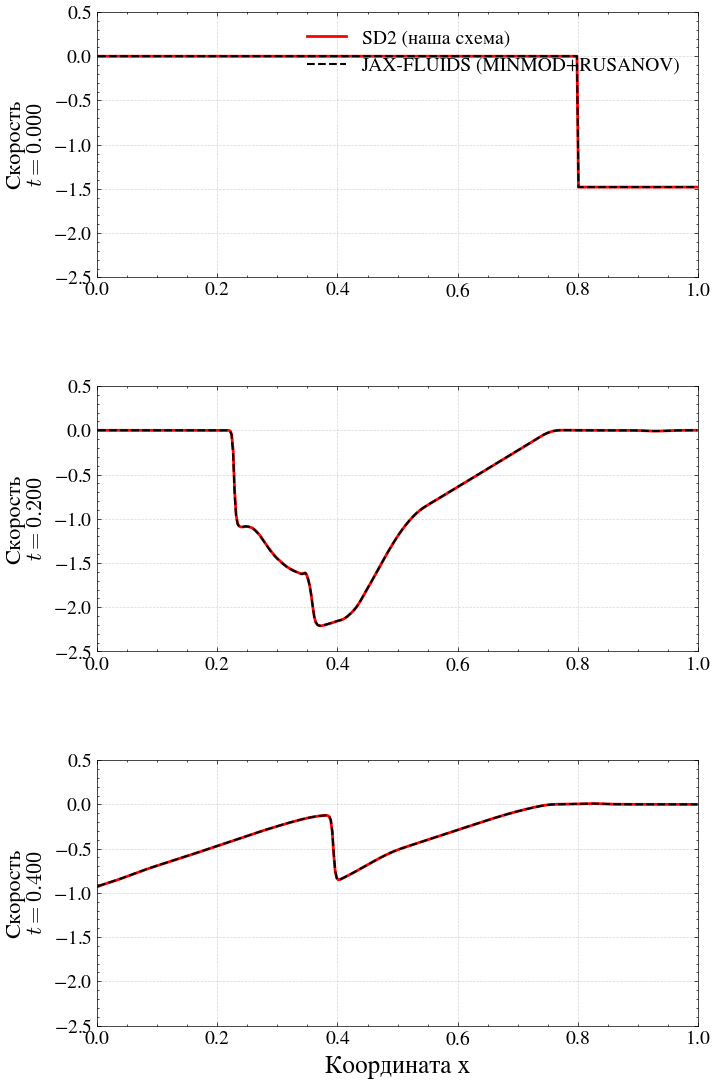

Сохранено: verify_1d_velocity.png


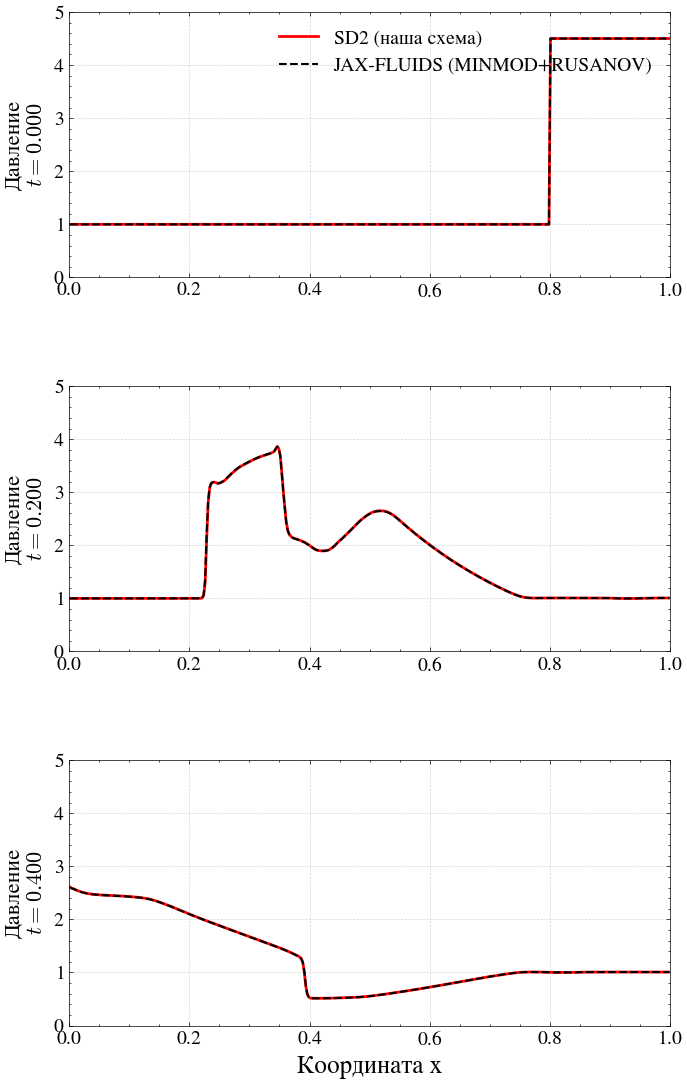

Сохранено: verify_1d_pressure.png


In [16]:
# ============================================================
# 6. ОТРИСОВКА
# Формат: 3 отдельные фигуры (rho, u, p),
# внутри каждой — 3 subplot'а для t=0, 0.2, 0.4
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({
    'font.size':        16,
    'axes.labelsize':   18,
    'axes.titlesize':   16,
    'legend.fontsize':  14,
    'xtick.labelsize':  14,
    'ytick.labelsize':  14,
})

plot_cfg = [
    {
        "label":    r"Плотность $\rho$",
        "ylabel":   r"Плотность",
        "ylim":     (0.0, 3.0),
        "my_data":  rho_my_list,
        "jf_data":  rho_jf_list,
        "fname":    "verify_1d_rho.png",
    },
    {
        "label":    r"Скорость $u$",
        "ylabel":   r"Скорость",
        "ylim":     (-2.5, 0.5),
        "my_data":  u_my_list,
        "jf_data":  u_jf_list,
        "fname":    "verify_1d_velocity.png",
    },
    {
        "label":    r"Давление $p$",
        "ylabel":   r"Давление",
        "ylim":     (0.0, 5.0),
        "my_data":  p_my_list,
        "jf_data":  p_jf_list,
        "fname":    "verify_1d_pressure.png",
    },
]

for cfg in plot_cfg:
    fig, axes = plt.subplots(3, 1, figsize=(8, 12))
    fig.tight_layout(pad=3.5)

    for ax, t_val, my_data, jf_data in zip(
        axes, save_times, cfg["my_data"], cfg["jf_data"]
    ):
        ax.plot(x_num, my_data,  'r-',  lw=2,   label='SD2 (наша схема)')
        ax.plot(x_jf,  jf_data,  'k--', lw=1.5, label='JAX-FLUIDS (MINMOD+RUSANOV)')

        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(*cfg["ylim"])
        ax.set_ylabel(f"{cfg['ylabel']}\n$t = {t_val:.3f}$", fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(True, linestyle='--', alpha=0.5)

        # Легенду только на верхнем subplot'е
        if ax is axes[0]:
            ax.legend(loc='upper right')

    axes[-1].set_xlabel('Координата x', fontsize=18)

    plt.savefig(cfg["fname"], dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Сохранено: {cfg['fname']}")